In [1]:
from quadcoil import (
    quadcoil, SurfaceJAX, QuadcoilParams, 
    least_square_meshing, 
    SurfaceRZFourierJAX, SurfaceXYZTensorFourierJAX,
    project_points_to_rz_plane,
    project_points_to_plane,
    project_points_to_known_plane,
    raytrace_to_plane,
    max_lse,
    reconstruct_3d_from_plane
)
from quadcoil.winding_surface import _polygon_self_intersection, bisect_phi
from quadcoil.quantity import K_theta, Phi_with_net_current, K2, K
from quadcoil.io import simsopt_coil_from_qp
from quadcoil.plotting import gamma_to_vtk, gamma_and_scalar_field_to_vtk, gamma_and_field_to_vtk
from jax import jit, eval_shape, vmap
from functools import partial
from interpax import interp2d
import equinox
from jaxlib._jax import XlaRuntimeError

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
import time
import lineax as lx

In [3]:
from simsopt import load
from simsopt.geo import curves_to_vtk
from simsopt.field import BiotSavart
from simsopt.objectives.fluxobjective import SquaredFlux

## Loading data

In [4]:
# The example is li383.
_, plasma_surface = load('surfaces.json')
net_poloidal_current_amperes = 11884578.094260072
import jax
jax.config.update('jax_enable_x64', True)
plasma_surface_jax = SurfaceJAX.from_simsopt(plasma_surface)
# plasma_surface_jax = SurfaceJAX.from_simsopt(load('serial1149928.json')[0][1])

<class 'quadcoil.surface.SurfaceRZFourierJAX'>


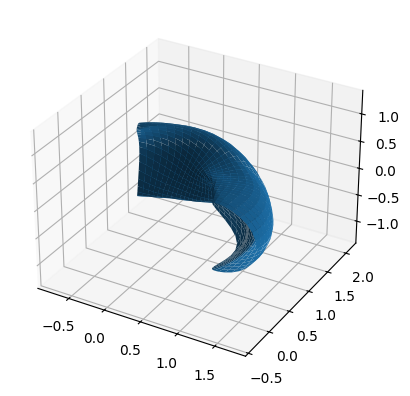

In [5]:
print(type(plasma_surface_jax))
plasma_surface_jax.plot()

In [6]:
plasma_surface_jax.mpol

8

In [7]:
offset = plasma_surface_jax.uniform_offset(
    d_expand=.5, 
    # surface_type=SurfaceXYZTensorFourierJAX,
    quadpoints_phi=jnp.linspace(0, 1/3, 100), 
    quadpoints_theta=jnp.linspace(0, 1, 100), 
)
gamma_to_vtk(offset.gamma(), 'test2')

# Experimental: General offset surface
Goal: now that we have exact uniform offset surfaces, 
we'll try implementing a new mechanism for generating 
winding surfaces by toroidaly shifting quadrature points 
on a winding surface to lie on projection planes, 

In [8]:
# Params
self = plasma_surface_jax
d_expand =  0.6
phi_interp = 2
theta_interp = 5
theta_rule_subsample = 5
quadpoints_phi = jnp.linspace(0, 1, self.nfp*100)
quadpoints_theta = jnp.linspace(0, 1, 100)
lam_tikhonov = 1e-3
mpol=7
ntor=7
theta_mode = 'arclen'
rule = 'self-intersection'
weight_mode = None

if weight_mode is None:
    if cls == SurfaceRZFourierJAX: 
        # For RZFourier surfaces, the inboard 
        # sections often has complex feature
        # with small element size. This needs 
        # to be treated carefully. So we weigh 
        # only by the poloidal arclen.
        weight_mode = 'poloidal_arclen'
    else:
        # For xyz tensor surfaces, there's a bigger
        # likelihood that the fit planes collide. When 
        # this happens, using the area of each element
        # to weigh can remove this type of artifacts better.
        # weight for each point. This is another place 
        # where toroidal wrapping is helpful. It allows 
        # us to estimate the area element connected to 
        # each fit points.
        weight_mode = 'area'
    
cls = type(self)
# Defining quadpoints
self_n_phi = len(self.quadpoints_phi)
self_n_theta = len(self.quadpoints_theta)
# Only process half a FP for stellsym configs
if self.stellsym:
    n_phi_target = (self_n_phi * phi_interp + 1) // 2
else:
    n_phi_target = self_n_phi * phi_interp
n_theta_target = self_n_theta * theta_interp 
# The sample CONTAINS endpoints in PHI AND THETA
# Convention: 
# - Grids quantities wrapped in the toroidal 
#   direction only will be marked with _tw.
# - Grids quantities wrapped in the poloidal 
#   direction only will be marked with _pw.
# - Grids quantities wrapped in the both 
#   directions will be marked with _tpw.
# We generate a uniform offset surface wrapped 
# in the toroidal surface. This wrapping will be useful
# when assigning phi parameterization and weights to 
# each sample point.
quadpoints_phi_sample_tw = jnp.linspace(
    0, 0.5/self.nfp if self.stellsym else 1/self.nfp,
    n_phi_target+1,
    endpoint=True
)
quadpoints_theta_sample = jnp.linspace(
    0, 1, 
    n_theta_target, 
    endpoint=False
)
source_surface_tw = self.copy_and_set_quadpoints(
    quadpoints_phi=quadpoints_phi_sample_tw, 
    quadpoints_theta=quadpoints_theta_sample, 
)
# Generating an exact offset surface.
offset_surface_tw = source_surface_tw.uniform_offset(d_expand=d_expand)
# shapes: [n_phi_target+1, n_theta_target, 3]
gamma_uniform_tw = offset_surface_tw.gamma()
gammadash1_uniform_tw = offset_surface_tw.gammadash1()
gammadash2_uniform_tw = offset_surface_tw.gammadash2()
# Finding fit planes to poloidal sections
# ----- Extract R, Z coordinates -----

batched_reproject = vmap(project_points_to_known_plane, in_axes=(0, 0), out_axes=(0, 0))
if cls == SurfaceRZFourierJAX:
    batched_project = vmap(project_points_to_rz_plane, in_axes=(0, 0, 0), out_axes=(0, 0, 0))
else:
    # New approach: plane-fit each poloidal slice
    # Apply vmap over toroidal dimension (axis 0)
    batched_project = vmap(project_points_to_plane, in_axes=(0, 0, 0), out_axes=(0, 0, 0))

In [9]:
# Estimate of each plane's normal vector. 
# To make sure that every plane's normal 
# is oriented to the same direction.
# May be unnecessary and a source of AD instability, 
# but left in for stability for now.
# shapes: [n_phi_target+1, 3]
normals_for_sign_tw = jnp.average(gammadash1_uniform_tw * offset_surface_tw.da()[:, :, None], axis=1)
# Conduct plane fits. Here, we throw away the theta end points 
# to avoid double counting. Rolled along toroidal, but not toroidal
# directions.
# Shapes: [n_phi_target+1, n_theta_target]
R_pol, Z_pol, plane_data_tw = batched_project(gamma_uniform_tw, normals_for_sign_tw, offset_surface_tw.da())
# Initializing phi and theta grid.
# Shapes: [n_phi_target, n_theta_target]
phi_grid_tw, theta_grid_tw = jnp.meshgrid(quadpoints_phi_sample_tw, quadpoints_theta_sample)
phi_grid_tw = phi_grid_tw.T
theta_grid_tw = theta_grid_tw.T

In [10]:
%%time
try:
    phi_grid_bisect_tw = bisect_phi(offset_surface_tw, plane_data_tw)
except XlaRuntimeError: 
    raise ValueError('Winding surface smoothing failed. There may be toroidal self-intersection.')
gamma_pol_bisect_tw = offset_surface_tw.gamma_at_point(phi_grid_bisect_tw, theta_grid_tw)

CPU times: user 867 ms, sys: 45.8 ms, total: 913 ms
Wall time: 1.11 s


In [11]:
%%time
# Shapes: [n_phi_target+1, n_theta_target]
r_pol_new_tw, z_pol_new_tw = batched_reproject(gamma_pol_bisect_tw, plane_data_tw)
# Shapes: [n_phi_target, n_theta_target]
r_pol_new, z_pol_new = r_pol_new_tw[:-1, :], z_pol_new_tw[:-1, :]
# ----- Calculating parameterization -----
r_pol_new_tpw = jnp.pad(r_pol_new_tw, pad_width=((0, 0), (0, 1)), mode='wrap')
z_pol_new_tpw = jnp.pad(z_pol_new_tw, pad_width=((0, 0), (0, 1)), mode='wrap')
# Compute the differences along axis=1 (between successive points)
dr_tw = jnp.diff(r_pol_new_tpw, axis=1)
dz_tw = jnp.diff(z_pol_new_tpw, axis=1)
# Compute the Euclidean distance for each segment
# Shapes: [n_phi_target+1, n_theta_target]
seglengths_tw = jnp.sqrt(dr_tw**2 + dz_tw**2)
# Sum the segment lengths to get the total arclength for each curve
# Shapes: [n_phi_target+1, n_theta_target]
arclengths_tw = jnp.cumsum(seglengths_tw, axis=1)
# Shapes: [n_phi_target, n_theta_target]
arclengths = arclengths_tw[:-1, :]

CPU times: user 120 ms, sys: 9.74 ms, total: 130 ms
Wall time: 210 ms


In [12]:

# ----- Removing self-intersection -----
# Removing self-intersections
# we now re-project the newton-shifted points to the 
# best-fit planes, and scan for self-intersections
# using their projection in the best-fit planes.
if rule == 'self-intersection':
    rule_f = _polygon_self_intersection
elif rule == 'hull':
    rule_f = _graham_scan
else:
    raise ValueError('rule must to be \'intersection\' '
                     'or \'hull\'. The current value is: '+ rule)
    
weight_subsample = vmap(rule_f, in_axes=0)(r_pol_new[:, ::theta_rule_subsample], z_pol_new[:, ::theta_rule_subsample])
batch_interp = vmap(jnp.interp, in_axes=(0, 0, 0), out_axes=0)
weight_remove_invalid = batch_interp(
    arclengths,
    arclengths[:, ::theta_rule_subsample],
    weight_subsample,
)

In [13]:


# ----- Assigning theta to fit points -----
# Generates an array called theta_target
# Shapes: [n_phi_target, n_theta_target]
if theta_mode == 'arctan':
    theta_target = jnp.arctan2( 
        z_pol_new,
        r_pol_new,
    ) / jnp.pi / 2 + 0.5
    theta_target = jnp.unwrap(theta_target, period=1)
elif theta_mode == 'arclen':
    # First we select the point closest to the axis' projection
    # on the ourboard side as the origin
    theta_target = (arclengths - arclengths[:, 0][:, None]) / arclengths[:, -1][:, None]
    # The outboard side tends to be concave. 
    # First we eliminate all points with r smaller
    # than the axis.
    z_for_proj = jnp.where(
        r_pol_new > 0,
        z_pol_new, jnp.inf
    )
    ind_proj = jnp.argmin(z_for_proj**2, axis=1)
    # Then we shift the theta based on the the 
    # theta closest to the z center of the plasma surface
    theta_shift = theta_target[jnp.arange(theta_target.shape[0]), ind_proj][:, None]
    theta_target = theta_target - theta_shift
else:
    raise NotImplementedError('theta_mode muse be \'arctan\' or \'arclen\'. The current value is: '+ theta_mode)
# Now, we need to make theta respect stellsym. 
# we know that the [0, :] poloidal section is the symmetry surface
# and needs to be symmetrical w.r.t. an axis going through the
# theta = 0 and theta = 0.5 points.
if self.stellsym:
    # First, make sure that the symmetry point has theta=0.
    theta_target = theta_target - theta_target[0, 0]
    # Second, make sure that theta[n] - 1/n is anti-symmetric.
    theta_pert = (theta_target-quadpoints_theta_sample)[0, 1:]
    # Average (theta-1/n) of the symmetry plane (excluding at the symmetric
    # point) with its reflection
    theta_pert2 = (theta_pert - np.flip(theta_pert))/2
    theta_target = theta_target.at[0, 1:].set(theta_pert2 + quadpoints_theta_sample[1:])



In [14]:

# ----- Assigning phi to fit points -----
# The toroidal angle of each plane is determined 
# by the arclen of the axis. The toroidal 
# wrapping all the way back when defining 
# quadpoints_phi_sample_tw
# Shape: [n_phi_target]
axis_seglengths = jnp.linalg.norm(jnp.diff(plane_data_tw['origin'], axis=0), axis=1)
# The cumsum call tosses the first element. Here we add it back.
# Shape: [n_phi_target+1]
axis_arclengths_tw = jnp.insert(jnp.cumsum(axis_seglengths), 0, 0.)
# The wrapping now comes in handy. It allows us to properly
# normalize toroidal axis arclen into an angular variable. 
# without wrapping the length of the last element will be improperly
# treated
quadpoints_phi_new_tw = axis_arclengths_tw / axis_arclengths_tw[-1] * quadpoints_phi_sample_tw[-1]
# Shape: [n_phi_target, n_theta_target]
phi_target, theta_target = jnp.broadcast_arrays(quadpoints_phi_new_tw[:-1, None], theta_target)


In [15]:

if weight_mode == 'poloidal_arclen':
    weights = seglengths_tw[:-1, :] #  * quadpoints_phi_new_tw[:-1, None]
elif weight_mode == 'area':
    gamma_pol_bisect_tpw = jnp.pad(gamma_pol_bisect_tw, pad_width=((0, 0), (0, 1), (0, 0)), mode='wrap')
    weights = jnp.linalg.norm(jnp.cross(
        gamma_pol_bisect_tpw[1:, :-1] - gamma_pol_bisect_tpw[:-1, :-1],
        gamma_pol_bisect_tpw[:-1, 1:] - gamma_pol_bisect_tpw[:-1, :-1],
        axis=-1
    ), axis=-1)
else:
    raise NotImplementedError('weight_mode muse be \'poloidal_arclen\' or \'area\'. The current value is: '+ weight_mode)
    
# Remove the toroidal wrapping to get the actuak
# least-square fit points.
gamma_pol_bisect = gamma_pol_bisect_tw[:-1, :]

In [18]:
gamma_and_scalar_field_to_vtk(gamma_pol_bisect, weight_remove_invalid* weights, 'weights')

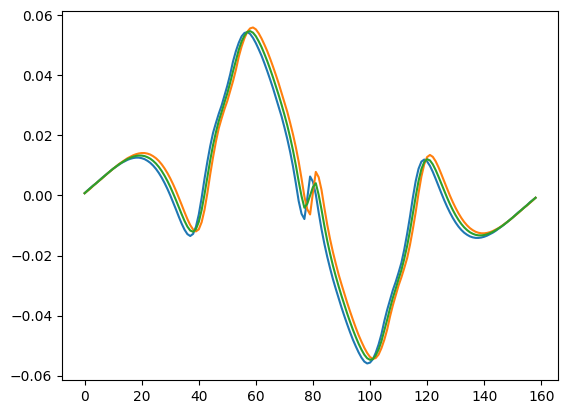

In [19]:
plt.plot(theta_pert)
plt.plot(- np.flip(theta_pert))
plt.plot(theta_pert2)

In [20]:
r_origins = jnp.sqrt(plane_data_tw['origin'][:, 0]**2 + plane_data_tw['origin'][:, 0]**2)

In [21]:
fit_surface = cls.fit(
    phi_target=phi_target, 
    theta_target=theta_target,
    gamma_target=gamma_pol_bisect,
    nfp=self.nfp, 
    stellsym=True, # self.stellsym,
    quadpoints_phi=quadpoints_phi,
    quadpoints_theta=quadpoints_theta,
    mpol=mpol, 
    ntor=ntor,
    lam_tikhonov=lam_tikhonov,
    custom_weight= weight_remove_invalid * weights
)

In [23]:
fit_surface.to_simsopt().to_vtk('fit_surface')

# Testing on tensor surface

In [14]:
%%time
phi_grid_tw, theta_grid_tw = least_square_meshing(
    surf=plasma_surface_jax, 
    quadpoints_phi_offset=quadpoints_phi_offset, 
    quadpoints_theta_offset=quadpoints_theta_offset, 
    mpol=6, ntor=6, 
    d_expand=0.2
)

CPU times: user 19.9 ms, sys: 5.86 ms, total: 25.7 ms
Wall time: 24.9 ms


In [151]:
gamma_and_scalar_field_to_vtk(gamma_uniform_tw, phi_grid_tw, 'phi_grid_tw')
gamma_and_scalar_field_to_vtk(gamma_uniform_tw, theta_grid_tw, 'theta_grid_tw')
gamma_and_scalar_field_to_vtk(gamma_uniform_tw, da, 'da')

NameError: name 'da' is not defined

In [9]:
(
    gamma_offset,
    dphi, dtheta, da,
    quadpoints_phi_rolled, 
    quadpoints_theta_rolled
) = self._gamma_offset(
    d_expand, 
    phi_interp=phi_interp,
    theta_interp=theta_interp,
    endpoint=True
)


In [22]:
offset2 = plasma_surface_jax2.uniform_offset(
    d_expand=-0, 
    mpol=7, ntor=7,
    quadpoints_phi=jnp.linspace(0, 1, 300), 
    quadpoints_theta=jnp.linspace(0, 1, 100), 
    phi_interp=2, theta_interp=2,
)
offset2.to_simsopt().to_vtk('test2')
(
    gamma_uniform_tw2, _, 
    quadpoints_phi_offset2, 
    quadpoints_theta_offset2
) = plasma_surface_jax2._gamma_offset(
    d_expand=-.0, 
    phi_interp=2,
    theta_interp=2,
)
phi_grid_tw2, theta_grid_tw2 = least_square_meshing(
    surf=plasma_surface_jax2, 
    quadpoints_phi_offset=quadpoints_phi_offset2, 
    quadpoints_theta_offset=quadpoints_theta_offset2, 
    mpol=7, ntor=7, 
    d_expand=-0.0
)
gamma_and_scalar_field_to_vtk(gamma_uniform_tw2, phi_grid_tw2, 'phi_grid_tw2')
gamma_and_scalar_field_to_vtk(gamma_uniform_tw2, theta_grid_tw2, 'theta_grid_tw2')

In [ ]:
plasma_surface_jax2

# Failed experiments

In [ ]:
@jit
def iterate_phi2(phi_grid_tw, damping_factor=1.):
    """Second-order (Halley) Newton iteration in phi.

    For each (i, j) on the (n_phi, n_theta) grid, shift phi so that
    ``offset_surface_tw.gamma_at_point(phi_grid_tw_new, theta_grid_tw)[i, j]`` lies on
    the i-th plane in ``plane_data_tw``.  The root of

        f(phi) = (gamma(phi, theta_ij) - origin_i) . normal_i

    is updated with one Halley step

        phi <- phi - 2 f f' / (2 (f')^2 - f f'')

    using first and second phi-derivatives obtained from
    ``offset_surface_tw.gammadash_at_point(., ., a, 0)`` with ``a = 1, 2``.
    """
    gamma = offset_surface_tw.gamma_at_point(phi_grid_tw, theta_grid_tw)
    g1    = offset_surface_tw.gammadash_at_point(phi_grid_tw, theta_grid_tw, 1, 0)
    g11   = offset_surface_tw.gammadash_at_point(phi_grid_tw, theta_grid_tw, 2, 0)

    o = plane_data_tw['origin'][:, None, :]
    n = plane_data_tw['normal'][:, None, :]

    f   = jnp.sum((gamma - o) * n, axis=-1)
    fp  = jnp.sum(g1  * n, axis=-1)
    fpp = jnp.sum(g11 * n, axis=-1)

    delta_phi = -2.0 * f * fp / (2.0 * fp * fp - f * fpp)
    return phi_grid_tw + damping_factor * delta_phi


phi_grid_tw2_halley = iterate_phi(phi_grid_tw, damping_factor=0.5)
gamma_pol_halley = offset_surface_tw.gamma_at_point(phi_grid_tw2_halley, theta_grid_tw)
gamma_and_scalar_field_to_vtk(gamma_pol_halley, phi_grid_tw, 'gamma_halley')

In [66]:
plasma_surface_sym = plasma_surface_jax.copy_and_set_quadpoints(
    quadpoints_phi=quadpoints_phi, 
    quadpoints_theta=quadpoints_theta, 
)
source_curvatures = plasma_surface_sym.surface_curvatures()

In [67]:
source_curvatures.shape

(32, 64, 4)

In [68]:
weight = jnp.where()

TypeError: where() missing 1 required positional argument: 'condition'

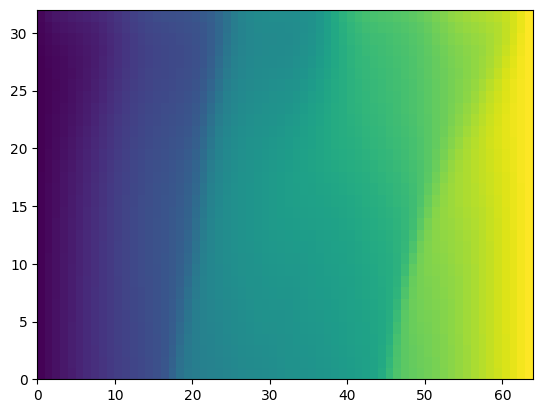

In [70]:
plt.pcolor(arclengths)

In [72]:
unitnormal_uniform_tw = offset_surface_tw.unitnormal()
jacobian = jnp.sum(unitnormal_uniform_tw*jnp.cross(gammadash1_uniform_tw, gammadash2_uniform_tw, axis=-1), axis=-1)
gamma_to_vtk(gamma_uniform_tw, 'test_gamma')
gamma_to_vtk(gamma_uniform_tw2, 'test_gamma2')
gamma_and_field_to_vtk(gamma_uniform_tw, gammadash1_uniform_tw, 'gammadash1_uniform_tw')
gamma_and_field_to_vtk(gamma_uniform_tw, unitnormal_uniform_tw, 'unitnormal_uniform_tw')
gamma_and_scalar_field_to_vtk(gamma_uniform_tw, theta_grid_tw, 'theta_grid_tw')
gamma_and_scalar_field_to_vtk(gamma_uniform_tw, source_curvatures[:, :, 0], 'source_curvatures0')
gamma_and_scalar_field_to_vtk(gamma_uniform_tw, source_curvatures[:, :, 1], 'source_curvatures1')
gamma_and_scalar_field_to_vtk(gamma_uniform_tw, source_curvatures[:, :, 2], 'source_curvatures2')
gamma_and_scalar_field_to_vtk(gamma_uniform_tw, source_curvatures[:, :, 3], 'source_curvatures3')
gamma_and_scalar_field_to_vtk(plasma_surface_sym.gamma(), source_curvatures[:, :, 0], 'plasma_curvatures0')
gamma_and_scalar_field_to_vtk(plasma_surface_sym.gamma(), source_curvatures[:, :, 1], 'plasma_curvatures1')
gamma_and_scalar_field_to_vtk(plasma_surface_sym.gamma(), source_curvatures[:, :, 2], 'plasma_curvatures2')
gamma_and_scalar_field_to_vtk(plasma_surface_sym.gamma(), source_curvatures[:, :, 3], 'plasma_curvatures3')
gamma_and_scalar_field_to_vtk(plasma_surface_sym.gamma(), jnp.where(source_curvatures[:, :, 2]>1/d_expand, source_curvatures[:, :, 3], 0), 'plasma_C')
gamma_and_scalar_field_to_vtk(gamma_uniform_tw, jnp.where(source_curvatures[:, :, 2]>1/d_expand, source_curvatures[:, :, 3], 0), 'plasma_C2')
gamma_and_scalar_field_to_vtk(gamma_uniform_tw, jacobian, 'jacobian_uniform_tw')
gamma_and_scalar_field_to_vtk(gamma_uniform_tw, arclengths, 'arclengths')


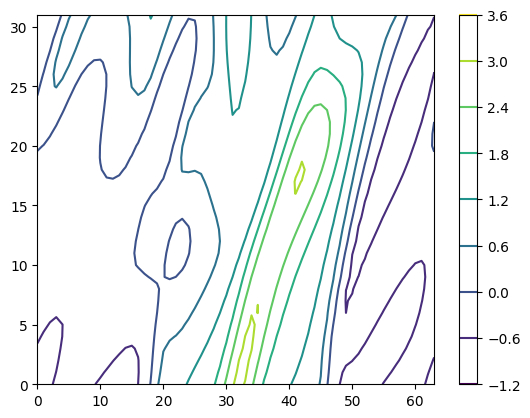

In [73]:
plt.contour(source_curvatures[:, :, 2])
plt.colorbar()

In [74]:
1/d_expand

1.6666666666666667

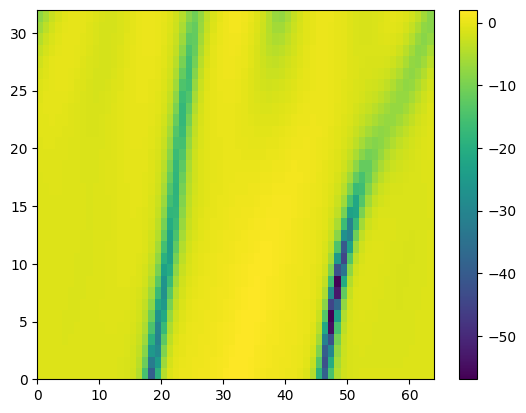

In [75]:
plt.pcolor(source_curvatures[:, :, 0])
plt.colorbar()


In [76]:
delta_phi = batched_raytrace(gamma_uniform_tw, gammadash1_uniform_tw, plane_data_tw)
gamma_and_scalar_field_to_vtk(gamma_uniform_tw, delta_phi, 'delta_phi')

In [77]:
def iterate_phi(phi_grid_tw_in, damping_factor=0.1):
    gamma_sample = offset_surface_tw.gamma_at_point(phi_grid_tw_in, theta_grid_tw)
    gammadash1_sample = offset_surface_tw.gammadash_at_point(phi_grid_tw_in, theta_grid_tw, 1, 0)
    delta_phi = batched_raytrace(gamma_sample, gammadash1_sample, plane_data_tw)
    return phi_grid_tw + damping_factor * delta_phi
# Shifting phi grid via a Newton iteration so that
# points projected from the same poloidal slice also ends
# up in the same fitted surface.


In [78]:
phi_grid_tw_in = phi_grid_tw
gamma_sample = offset_surface_tw.gamma_at_point(phi_grid_tw_in, theta_grid_tw)
gammadash1_sample = offset_surface_tw.gammadash_at_point(phi_grid_tw_in, theta_grid_tw, 1, 0)
gammadash2_sample = offset_surface_tw.gammadash_at_point(phi_grid_tw_in, theta_grid_tw, 0, 1)
gammadash1_unit = gammadash1_sample / jnp.linalg.norm(gammadash1_sample, axis=-1)[:, :, None]
gammadash2_unit = gammadash2_sample / jnp.linalg.norm(gammadash2_sample, axis=-1)[:, :, None]
shear = jnp.linalg.norm(jnp.cross(gammadash1_unit, gammadash2_unit, axis=-1), axis=-1)
delta_phi = batched_raytrace(gamma_sample, gammadash1_sample, plane_data_tw)
# return phi_grid_tw + damping_factor * shear * delta_phi

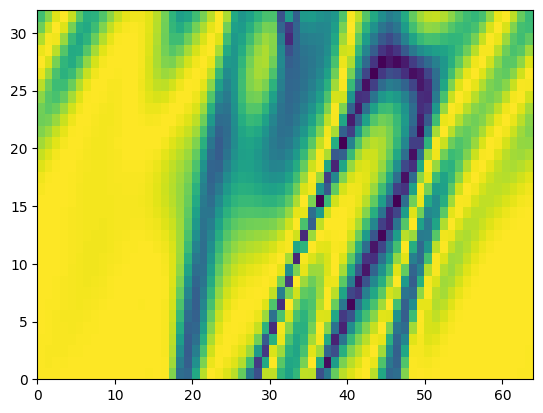

In [79]:
plt.pcolor(shear)

In [ ]:
grid_phi

In [48]:

gamma_and_scalar_field_to_vtk(gamma_sample, grid_phi, 'phi_grid_tw_bisection')

In [54]:
damping_factor = 0.5
phi_grid_tw2 = iterate_phi(phi_grid_tw, damping_factor)
phi_grid_tw3 = iterate_phi(phi_grid_tw2, damping_factor)
phi_grid_tw4 = iterate_phi(phi_grid_tw3, damping_factor)

gamma_pol_2 = offset_surface_tw.gamma_at_point(phi_grid_tw2, theta_grid_tw)
gamma_pol_3 = offset_surface_tw.gamma_at_point(phi_grid_tw3, theta_grid_tw)
gamma_pol_4 = offset_surface_tw.gamma_at_point(phi_grid_tw4, theta_grid_tw)


gamma_and_scalar_field_to_vtk(gamma_pol_2, phi_grid_tw, 'gamma_pol_2')
gamma_and_scalar_field_to_vtk(gamma_pol_3, phi_grid_tw, 'gamma_pol_3')
gamma_and_scalar_field_to_vtk(gamma_pol_4, phi_grid_tw, 'gamma_pol_4')